# Car Price Prediction using Machine Learning

# Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [4]:
df = pd.read_csv("car data.csv")

# Show Dataset


In [5]:
print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


# Dataset Information


In [6]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


# Check Missing Values


In [7]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


# -----------------------------------
# Data Preprocessing
# -----------------------------------

# Create Car Age Column

In [9]:
current_year = 2025

df['Car_Age'] = current_year - df['Year']


In [10]:

# Drop Year Column
df.drop('Year', axis=1, inplace=True)



In [11]:
# Convert Categorical Columns into Numerical
df = pd.get_dummies(df, drop_first=True)


In [12]:

# Show Processed Data
print("\nProcessed Data:\n")
print(df.head())


Processed Data:

   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  \
0           3.35           5.59       27000      0       11   
1           4.75           9.54       43000      0       12   
2           7.25           9.85        6900      0        8   
3           2.85           4.15        5200      0       14   
4           4.60           6.87       42450      0       11   

   Car_Name_Activa 3g  Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  \
0               False               False                   False   
1               False               False                   False   
2               False               False                   False   
3               False               False                   False   
4               False               False                   False   

   Car_Name_Bajaj Avenger 150  Car_Name_Bajaj Avenger 150 street  ...  \
0                       False                              False  ...   
1                       False             

# -----------------------------------
# Split Dataset
# -----------------------------------


In [13]:

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -----------------------------------
# Train Machine Learning Model
# -----------------------------------



In [14]:
model = LinearRegression()

model.fit(X_train, y_train)




LinearRegression()

# Predictions


In [15]:

y_pred = model.predict(X_test)

# -----------------------------------
# Model Evaluation
# -----------------------------------


In [16]:


print("\nMean Absolute Error:")
print(mean_absolute_error(y_test, y_pred))

print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))


Mean Absolute Error:
2.0365174789886256

Mean Squared Error:
9.221090391450879

R2 Score:
0.5997023481939978


# -----------------------------------
# Actual vs Predicted Graph
# -----------------------------------



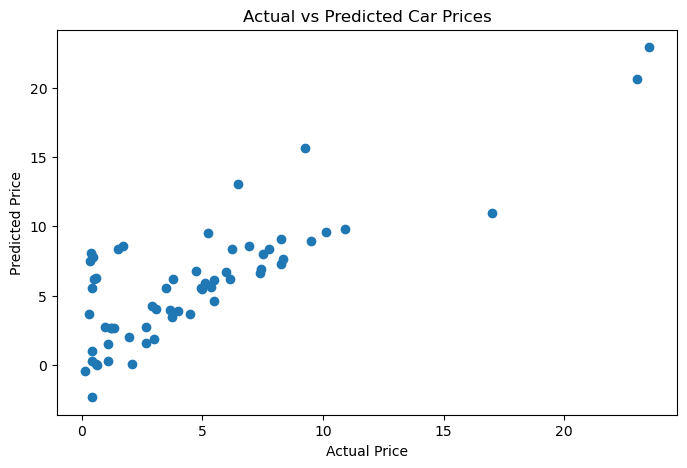

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

# -----------------------------------
# Predict Price of First Car
# -----------------------------------


In [19]:

sample = X.iloc[0].values.reshape(1, -1)

predicted_price = model.predict(sample)

print("\nPredicted Car Price:")
print(predicted_price[0])

print("\nCar Price Prediction Completed Successfully!")



Predicted Car Price:
3.8130245928481488

Car Price Prediction Completed Successfully!


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
